<a href="https://colab.research.google.com/github/prasadw350-lang/Assignments/blob/main/Assignment27.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Q1. (Creating Non-Linear Dataset)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_moons

In [2]:
X, y = make_moons(
    n_samples=500,
    noise=0.05,
    random_state=42
)

In [3]:
df = pd.DataFrame(
    X,
    columns=["Feature1", "Feature2"]
)

df.head(10)

print(df.shape)

(500, 2)


Q2. (Scaling the Data)

In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(df)

print(X_scaled[:5])

[[ 0.37512461 -1.40367864]
 [ 0.22681458  1.13562771]
 [ 0.59544154 -1.49371022]
 [-0.94491835  1.40974769]
 [-0.24311512  1.61806199]]


Q3. (K-Means on Non-Linear Data)

In [5]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=2,
    random_state=42
)

df["kmeans_cluster"] = kmeans.fit_predict(X_scaled)

df.head()

,Feature1,Feature2,kmeans_cluster
0,0.830586,-0.447733,1
1,0.701678,0.816918,0
2,1.022080,-0.492571,1
3,-0.316765,0.953438,0
4,0.293226,1.057185,0


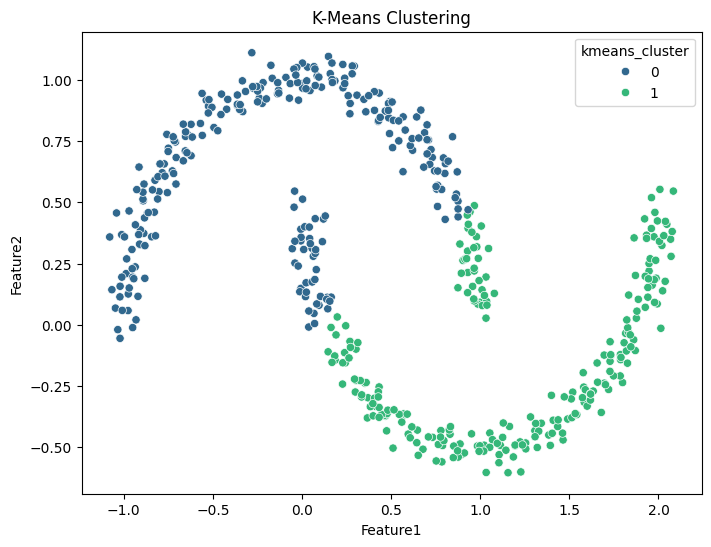

In [6]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Feature1",
    y="Feature2",
    hue="kmeans_cluster",
    palette="viridis"
)

plt.title("K-Means Clustering")
plt.show()

Q4. (DBSCAN Clustering)

In [7]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=0.3,
    min_samples=5
)

df["dbscan_cluster"] = dbscan.fit_predict(X_scaled)

df.head()

,Feature1,Feature2,kmeans_cluster,dbscan_cluster
0,0.830586,-0.447733,1,0
1,0.701678,0.816918,0,1
2,1.022080,-0.492571,1,0
3,-0.316765,0.953438,0,1
4,0.293226,1.057185,0,1


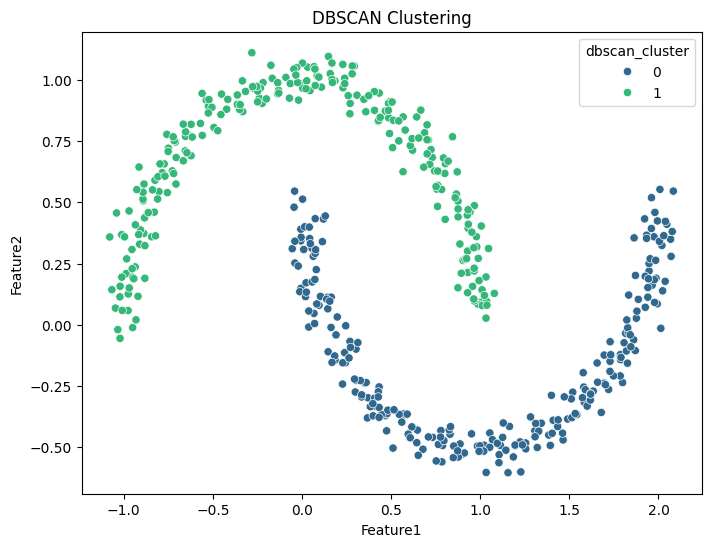

In [8]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Feature1",
    y="Feature2",
    hue="dbscan_cluster",
    palette="viridis"
)

plt.title("DBSCAN Clustering")
plt.show()

Q5. (Comparing KMeans vs DBSCAN)

In [9]:
print("K-Means Clusters:")
print(df["kmeans_cluster"].value_counts())

print("\nDBSCAN Clusters:")
print(df["dbscan_cluster"].value_counts())

K-Means Clusters:
kmeans_cluster
0    255
1    245
Name: count, dtype: int64

DBSCAN Clusters:
dbscan_cluster
0    250
1    250
Name: count, dtype: int64


1. K-Means divides the moon-shaped dataset into circular clusters.
2. DBSCAN correctly identifies the moon-shaped clusters.
3. DBSCAN automatically detects noise points (-1).

Q6. (Tuning DBSCAN Parameters)

In [27]:
results = []

for eps in [0.2, 0.3, 0.4, 0.5]:

    dbscan = DBSCAN(
        eps=eps,
        min_samples=5
    )

    labels = dbscan.fit_predict(X_scaled)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

    noise = list(labels).count(-1)

    results.append([eps, n_clusters, noise])

In [11]:
comparison = pd.DataFrame(
    results,
    columns=[
        "eps",
        "Clusters",
        "Noise Points"
    ]
)

comparison

,eps,Clusters,Noise Points
0,0.2,2,0
1,0.3,2,0
2,0.4,2,0
3,0.5,2,0


Q7. (Creating High-Dimensional Dataset)

In [12]:
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

In [13]:
X, y = make_blobs(
    n_samples=500,
    n_features=6,
    centers=4,
    cluster_std=1.5,
    random_state=42
)

In [14]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

Q8. (Applying PCA)

In [15]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

In [16]:
import pandas as pd

pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_df["Cluster"] = y

pca_df.head()

,PC1,PC2,Cluster
0,2.369765,1.259783,1
1,-0.943367,-0.829777,3
2,0.982191,-1.768556,0
3,2.265086,1.190377,1
4,2.142129,0.840804,1


In [17]:
print(pca.explained_variance_ratio_)

[0.64327878 0.21039738]


Q9. (Visualizing PCA Results)

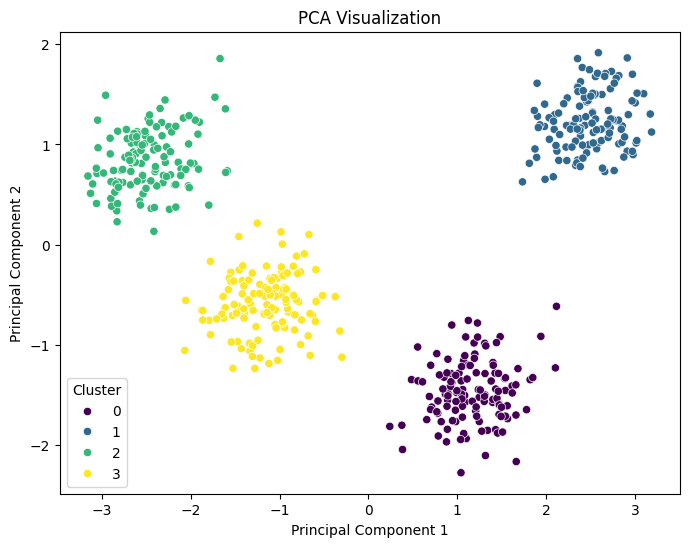

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="viridis"
)

plt.title("PCA Visualization")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

The explained variance ratio shows how much information is retained by each principal component. A higher value means that component preserves more of the original data's variance. Together, PC1 and PC2 retain most of the important information while reducing the dataset to two dimensions.

Q10. (Mini Project – Complete Pipeline)

In [19]:
from sklearn.datasets import load_iris
import pandas as pd

iris = load_iris()

df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [20]:
X = df

In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [22]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=0.5,
    min_samples=5
)

clusters = dbscan.fit_predict(X_scaled)

df["Cluster"] = clusters

In [23]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

In [24]:
pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1","PC2"]
)

pca_df["Cluster"] = clusters

pca_df.head()

,PC1,PC2,Cluster
0,-2.264703,0.480027,0
1,-2.080961,-0.674134,0
2,-2.364229,-0.341908,0
3,-2.299384,-0.597395,0
4,-2.389842,0.646835,0


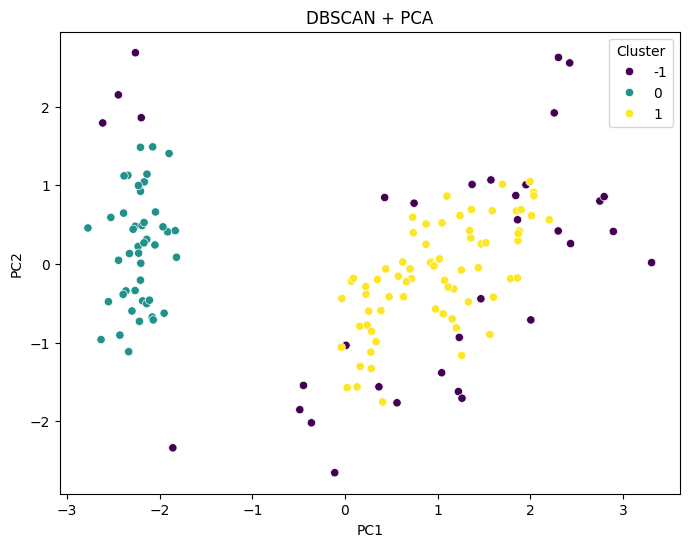

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="viridis"
)

plt.title("DBSCAN + PCA")

plt.show()

In [26]:
print(df["Cluster"].value_counts())

Cluster
 1    71
 0    45
-1    34
Name: count, dtype: int64


The Iris dataset was scaled using StandardScaler. DBSCAN was applied to identify clusters and detect noise points. PCA reduced the dataset to two principal components for easy visualization. The scatter plot shows the clustered data in a 2D space.